# Multi-Agent System for Kaggle Competition
## mws-ai-agents-2026: Rental Property Occupancy Prediction

This notebook runs the full multi-agent pipeline.

**Architecture**: LangGraph orchestrates 5 specialized agents:
- `DataAgent` — data loading, profiling, and LLM-guided cleaning
- `FeatureAgent` — LLM-planned feature engineering (datetime, geo, text, encodings)
- `ModelAgent` — trains LightGBM, XGBoost, and CatBoost with cross-validation
- `EvaluatorAgent` — computes MSE metrics and LLM interpretation
- `OrchestratorAgent` — decides ACCEPT or IMPROVE in a feedback loop

**LLM providers supported**: Groq, HuggingFace Inference, OpenRouter (default, large Nvidia model)

**Estimated runtime**: ~15–30 min on Colab T4 (depends on data size and iterations)

## 1. Install dependencies

In [ ]:
!git clone https://github.com/ArthurGaleev/kaggle-mas.git

Cloning into 'kaggle-mas'...
remote: Enumerating objects: 305, done.
remote: Counting objects: 100% (305/305), done.
remote: Compressing objects: 100% (216/216), done.
remote: Total 305 (delta 181), reused 160 (delta 87), pack-reused 0 (from 0)
Receiving objects: 100% (305/305), 211.60 KiB | 4.07 MiB/s, done.
Resolving deltas: 100% (181/181), done.


In [2]:
%cd kaggle-mas

/kaggle/working/kaggle-mas


In [3]:
# Install all project dependencies
%pip install -r requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 68.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.8 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os

# --- Option A: Groq  ---
# os.environ["GROQ_API_KEY"] = "your_groq_api_key_here"  # ← replace with your key

# --- Option B: HuggingFace Inference API ---
# os.environ["HF_TOKEN"] = "hf_your_token_here"

# --- Option C: OpenRouter --- (default, large Nvidia model)
# os.environ["OPENROUTER_API_KEY"] = "sk-or-your_key_here"

## 4. Download competition data

Choose one download method:

In [ ]:
# --- Method 1: Kaggle API (requires Kaggle credentials) ---
import os
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"]      = userdata.get('KAGGLE_KEY')

!kaggle competitions download -c mws-ai-agents-2026
!unzip -o mws-ai-agents-2026.zip -d data/
print("Data downloaded via Kaggle API")

# --- Method 2: Google Drive (public dataset mirror) ---
# !pip install -q gdown
# !mkdir -p data
# !gdown 1Xkag8BW9Q9phWyz1uQWyRVT311rG4tqp -O data.zip
# !unzip -o data.zip -d data/
# !ls data/
# print("Data downloaded via Google Drive")

100%|███████████████████████████████████████| 2.26M/2.26M [00:00<00:00, 130MB/s]

Archive:  mws-ai-agents-2026.zip
  inflating: data/sample_submition.csv  
  inflating: data/solution.csv       
  inflating: data/test.csv           
  inflating: data/train.csv          
Data downloaded via Kaggle API


## 5. (Optional) Inspect data

In [7]:
import pandas as pd

train = pd.read_csv("data/train.csv")
test  = pd.read_csv("data/test.csv")

print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")
print("\nTrain head:")
train.head()

Train shape : (36671, 15)
Test shape  : (12224, 14)

Train head:


,name,_id,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,last_dt,avg_reviews,total_host,target
0,Belle Harbor 4 BR 2 bath- 1 bl from Beach,40327248,Sarina,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,350,2,5,2019-07-07,2.88,1,334
1,"Come see Brooklyn, New York",13617520,Howard T.,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,40,5,8,2015-02-25,0.13,1,0
2,Large 2Br on W71st & Columbus Feb 19-28,26754726,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,200,5,0,NaN,NaN,1,0
3,Perfect bedroom. Near Subways Columbia CityCol...,16721721,Federico,Manhattan,Harlem,40.81530,-73.95080,Private room,65,2,18,2018-11-04,0.64,1,0
4,Cozy Sun Filled Fresh Guest Room in Artsy Bush...,22246463,Lisa,Brooklyn,Bushwick,40.70230,-73.92935,Private room,99,2,26,2019-06-23,0.76,1,155


In [8]:
print("Target statistics:")
print(train["target"].describe())

Target statistics:
count    36671.000000
mean       112.766628
std        131.583284
min          0.000000
25%          0.000000
50%         45.000000
75%        227.000000
max        365.000000
Name: target, dtype: float64


## 6. Run the full pipeline

The pipeline is configured via `configs/config.yaml`.

Default LLM provider is Groq — override with `llm=huggingface` or `llm=openrouter`.

In [9]:
# Run with default config (Groq LLM)
# !python main.py
!python main.py

[2026-03-29 20:22:13,246][kaggle-mas.main][INFO] - Config:
project:
  name: kaggle-mas-rental
  seed: 42
  data_dir: ./data
  output_dir: ./outputs
  log_dir: ./logs
  competition: mws-ai-agents-2026
pipeline:
  max_feedback_loops: 3
  target_mse_threshold: 8000.0
  cv_folds: 5
  test_size: 0.2
  enable_rag: true
  enable_guardrails: true
  enable_monitoring: true
  phases:
  - name: data_profiling
    agent: DataAgent
    timeout: 180
    retries: 2
  - name: data_cleaning
    agent: DataAgent
    timeout: 240
    retries: 2
  - name: feature_engineering
    agent: FeatureAgent
    timeout: 480
    retries: 3
  - name: model_training
    agent: ModelAgent
    timeout: 1200
    retries: 2
  - name: evaluation
    agent: EvaluatorAgent
    timeout: 300
    retries: 1
  - name: feedback_loop
    agent: OrchestratorAgent
    timeout: 180
    retries: 1
models:
  lightgbm:
    enabled: true
    params:
      n_estimators: 2000
      learning_rate: 0.03
      max_depth: 8
      num_leaves: 

In [ ]:
# --- Alternatives ---

# Use Groq
# !python main.py llm=groq

# Use HuggingFace Inference API
# !python main.py llm=huggingface

# Fast debug run (2 folds, no RAG, max 1 iteration)
# !python main.py pipeline=fast

# Custom data directory
# !python main.py project.data_dir=data/

## 7. Inspect results

In [10]:
import json

with open("outputs/pipeline_report.json") as f:
    report = json.load(f)

print(json.dumps(report, indent=2))

{
  "run_start": "2026-03-29T20:22:26.032042+00:00",
  "total_elapsed_s": 1837.3861,
  "phase_durations_s": {
    "DataAgent": 6.688,
    "input_validation": 0.0451,
    "FeatureAgent": 37.911,
    "feature_validation": 0.0525,
    "ModelAgent": 1020.07,
    "EvaluatorAgent": 36.3325,
    "output_validation": 0.001,
    "OrchestratorAgent": 0.0006,
    "full_pipeline": 1802.6696
  },
  "phase_statuses": {
    "DataAgent": "success",
    "input_validation": "success",
    "FeatureAgent": "success",
    "feature_validation": "success",
    "ModelAgent": "success",
    "EvaluatorAgent": "success",
    "output_validation": "success",
    "OrchestratorAgent": "success",
    "full_pipeline": "success"
  },
  "llm_calls": {
    "count": 0,
    "total_prompt_tokens": 0,
    "total_completion_tokens": 0,
    "avg_latency_s": 0.0
  },
  "model_metrics": {
    "lightgbm": {
      "validation/mse": [
        10465.805493057474,
        10558.497193760388,
        10082.381214663508,
        10205.

In [11]:
# View the submission file
sub = pd.read_csv("outputs/submission.csv")
print(f"Submission shape: {sub.shape}")
print(f"Prediction range: [{sub['prediction'].min():.2f}, {sub['prediction'].max():.2f}]")
print(f"Prediction mean : {sub['prediction'].mean():.2f}")
print(sub.head(10))

Submission shape: (12224, 2)
Prediction range: [0.00, 360.88]
Prediction mean : 112.83
   index  prediction
0      0  121.530824
1      1  186.586802
2      2  310.755886
3      3   45.662477
4      4   91.018551
5      5   24.732021
6      6    4.932232
7      7   42.722151
8      8   19.932144
9      9  256.134554


## 8. View monitoring dashboard

In [12]:
from monitoring.dashboard import MetricsDashboard
from monitoring.tracker import PipelineTracker
import os

os.makedirs("outputs/plots", exist_ok=True)

tracker = PipelineTracker.load("outputs/pipeline_report.json")
dashboard = MetricsDashboard()
dashboard.generate_report(tracker, "outputs/plots/")

print("Dashboard plots saved to outputs/plots/")

Dashboard plots saved to outputs/plots/


Found 3 plots:
  outputs/plots/feedback_loop_progress.png


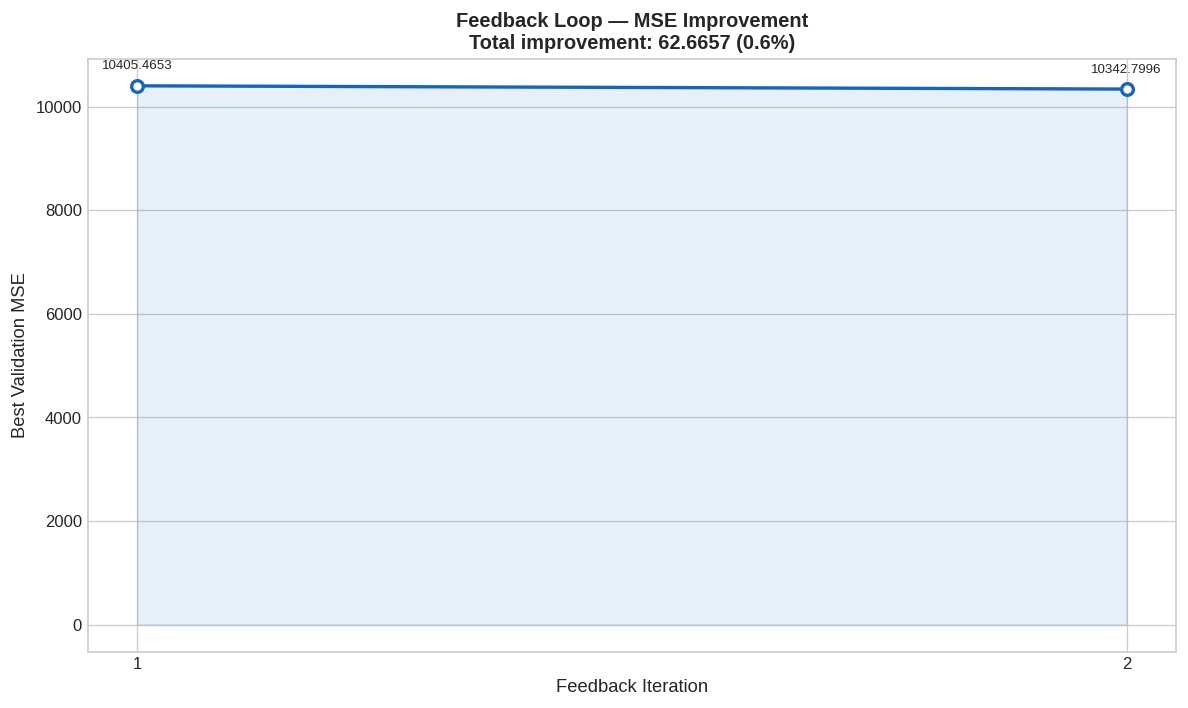

  outputs/plots/model_comparison.png


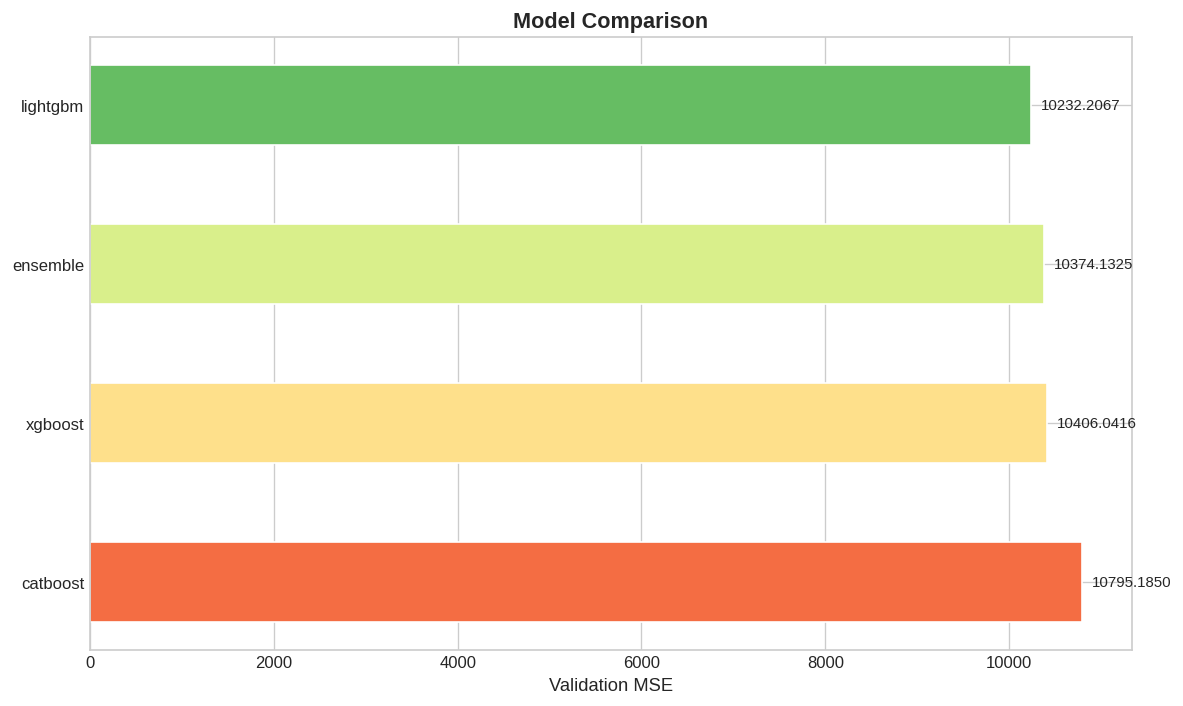

  outputs/plots/pipeline_timeline.png


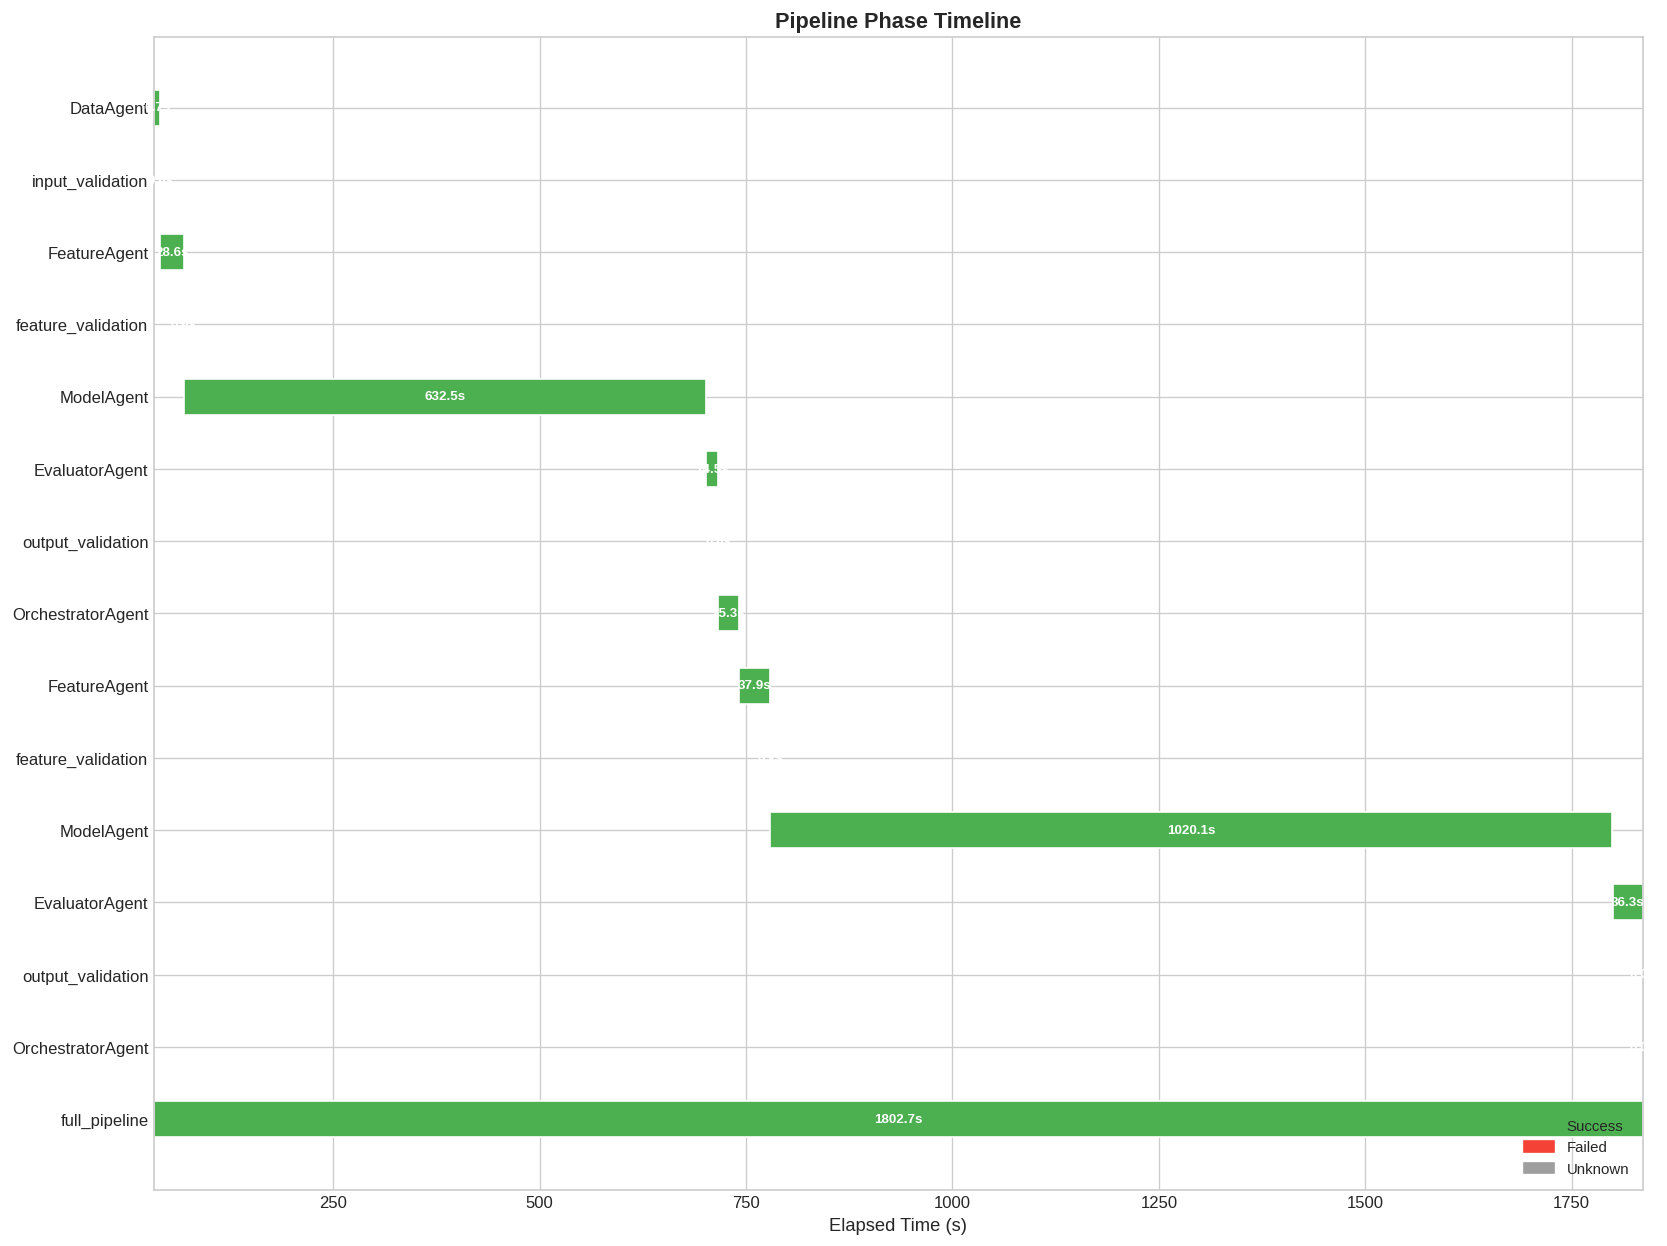

In [13]:
# Display all generated plots inline
from IPython.display import Image, display
import glob

plot_files = sorted(glob.glob("outputs/plots/*.png"))
print(f"Found {len(plot_files)} plots:")
for img_path in plot_files:
    print(f"  {img_path}")
    display(Image(filename=img_path))

## 9. (Optional) Hyperparameter sweep with Optuna

The ModelAgent uses Optuna internally, but you can run an explicit sweep:

In [ ]:
# !python main.py pipeline=fast pipeline.n_optuna_trials=50

## 10. Submit to Kaggle

In [14]:
# After verifying the submission looks correct, submit:
!kaggle competitions submit -c mws-ai-agents-2026 -f outputs/submission.csv -m "submission"

100%|█████████████████████████████████████████| 276k/276k [00:00<00:00, 822kB/s]
Successfully submitted to mws-ai-agents-2026

## Troubleshooting

| Problem | Solution |
|---------|----------|
| `GROQ_API_KEY not set` | Set `os.environ["GROQ_API_KEY"]` in cell 3 |
| OOM on T4 | Run with `pipeline=fast` to reduce memory usage |
| `data/train.csv not found` | Re-run cell 4 (download data) |
| Low MSE score | Try `pipeline.max_feedback_loops=3` for more iterations |
| Slow LLM calls | Switch to `llm=groq` for fastest inference |